**1: Import Libraries**

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

**2: Upload Dataset ZIP**

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

**3: Extract Dataset**

In [ ]:
import zipfile

with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


**4: Auto-Detect Dataset Path**

In [ ]:
import os

# Automatically find train folder
base_dir = None

for root, dirs, files in os.walk('/content/dataset'):
    if 'train' in dirs and 'val' in dirs and 'test' in dirs:
        base_dir = root
        break

print("Detected Dataset Path:", base_dir)

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

# Safety check
assert os.path.exists(train_dir), "Train folder not found!"
assert os.path.exists(val_dir), "Validation folder not found!"
assert os.path.exists(test_dir), "Test folder not found!"

print("Dataset structure OK ✅")

Detected Dataset Path: /content/dataset/dataset
Dataset structure OK ✅


**5: High-Quality Data Augmentation**

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

valid_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, # Changed from valid_dir to val_dir
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

Found 1084 files belonging to 2 classes.
Found 227 files belonging to 2 classes.
Found 238 files belonging to 2 classes.


**5.1: Strong Augmentation**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.05),

    layers.RandomContrast(0.05)

])

**5.2: Improve Dataset Performance**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

**6: Build Strong Model (MobileNetV3 Large)**

In [ ]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
base_model = MobileNetV3Large(

    input_shape=(224, 224, 3),

    include_top=False,

    weights='imagenet'

)

# Freeze base model first
base_model.trainable = False

model = Sequential([

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')

])

**7: Compile Model**

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,996,352 (11.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,996,352 (11.43 MB)

**8: Callbacks**

In [ ]:
early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=10,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=4,

    min_lr=1e-7,

    verbose=1
)

checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

callbacks = [
    early_stop,
    reduce_lr,
    checkpoint
]

**9: Initial Training**

In [ ]:
class_weight = {
    0: 1.0,   # clear
    1: 1.5    # hazard
}

initial_epochs = 25

history = model.fit(

    train_dataset,

    validation_data=valid_dataset,

    epochs=initial_epochs,

    callbacks=callbacks,

    class_weight=class_weight

)

Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6503 - loss: 0.8133
Epoch 1: val_accuracy improved from 0.72247 to 0.72687, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.6550 - loss: 0.7926 - val_accuracy: 0.7269 - val_loss: 0.5436 - learning_rate: 1.0000e-04
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6617 - loss: 0.7705
Epoch 2: val_accuracy did not improve from 0.72687
34/34 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6808 - loss: 0.7226 - val_accuracy: 0.7093 - val_loss: 0.5411 - learning_rate: 1.0000e-04
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6766 - loss: 0.7518
Epoch 3: val_accuracy did not improve from 0.72687
34/34 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6965 - loss: 0.7082 - val_accuracy: 0.7004 - val_loss: 0.5405 - learning_rate: 1.0000e-04
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7235 - loss: 0.6

**10: Fine-Tunning**

In [ ]:
base_model.trainable = True

# Freeze first layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']

)


fine_tune_epochs = 25

total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(

    train_dataset,

    validation_data=valid_dataset,

    epochs=total_epochs,

    initial_epoch=history.epoch[-1],

    callbacks=callbacks

)


Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6234 - loss: 0.6608
Epoch 11: val_accuracy did not improve from 0.72687
34/34 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6347 - loss: 0.6581 - val_accuracy: 0.6696 - val_loss: 0.5648 - learning_rate: 1.0000e-05
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6303 - loss: 0.6751
Epoch 12: val_accuracy did not improve from 0.72687
34/34 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6439 - loss: 0.6629 - val_accuracy: 0.6388 - val_loss: 0.5930 - learning_rate: 1.0000e-05
Epoch 13/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6525 - loss: 0.6310
Epoch 13: val_accuracy did not improve from 0.72687
34/34 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6697 - loss: 0.6198 - val_accuracy: 0.6388 - val_loss: 0.6234 - learning_rate: 1.0000e-05
Epoch 14/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6725 - loss: 0.6017
Epoch 14: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.



**11: Test Accuracy**

In [ ]:

test_loss, test_acc = model.evaluate(test_dataset)

print("Test Accuracy:", test_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 830ms/step - accuracy: 0.6723 - loss: 0.5890
Test Accuracy: 0.6722689270973206


**12: Plot Accuracy & Loss**

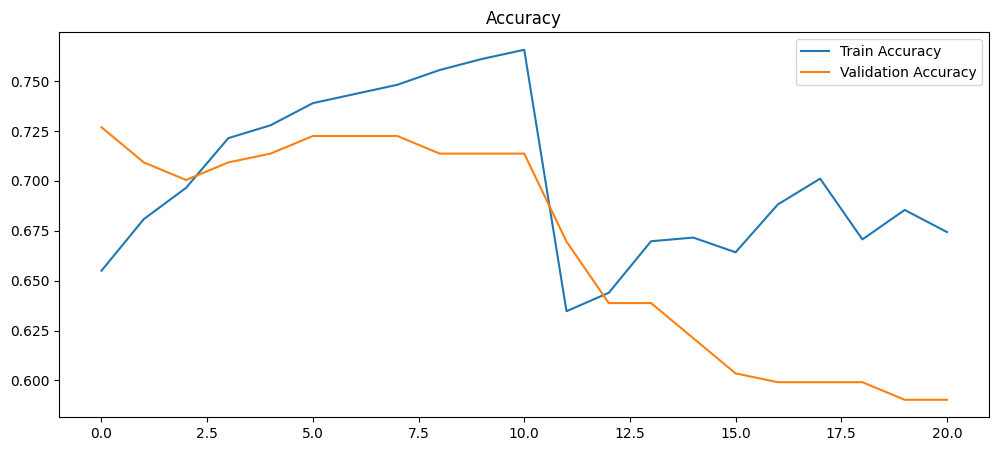

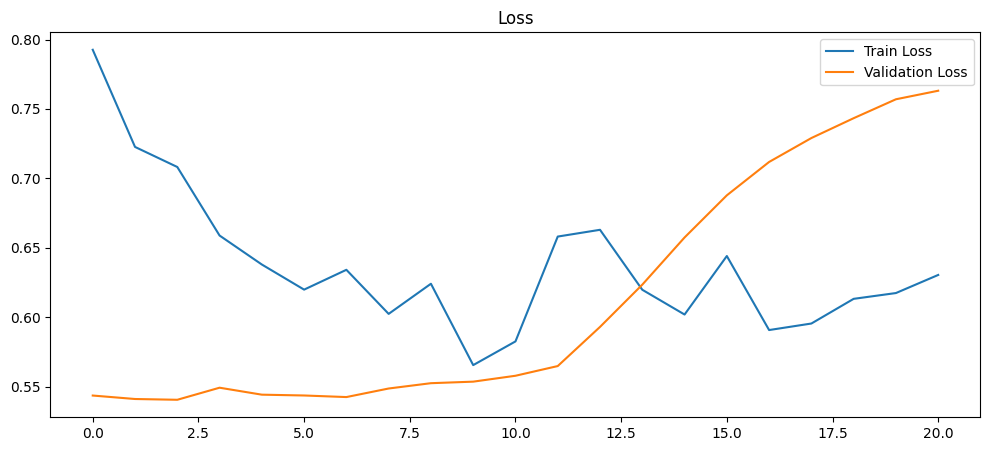

In [ ]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.legend()
plt.title('Accuracy')
plt.show()

# Loss Plot
plt.figure(figsize=(12,5))

plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend()
plt.title('Loss')
plt.show()

**12: Confusion Matrix**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


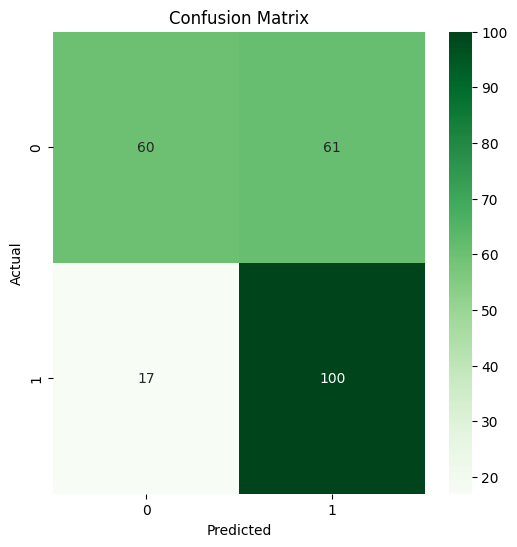

              precision    recall  f1-score   support

         0.0       0.78      0.50      0.61       121
         1.0       0.62      0.85      0.72       117

    accuracy                           0.67       238
   macro avg       0.70      0.68      0.66       238
weighted avg       0.70      0.67      0.66       238



In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print(classification_report(y_true, y_pred))